# Exploratory Data Analysis: Temporal and Vertical Patterns in Microbial ATP at Station ALOHA

## Research Question

How does microbial ATP concentration vary with depth and over time at Station ALOHA?

## Data Description and Access

This project uses water column data from the Hawaii Ocean Time series (HOT) program at the ALOHA station. This data set contains measurements collected during HOT cruises such as ATP measurements, CTD pressure, temperature, salinity, oxygen, and other biological variables. ATP concentrations are described in units of ng/kg and is used as a live microbial biomass proxy. CTD pressure is reported in dbar, which is converted using the approximation that 1 dbar is 1 m in depth. 

The data were accessed through HOT-webODV and downloaded as a text file. The analysis is collected from 1988 to 2024.
Mieruch, S. & Schlitzer, R., HOT-webODV, https://hot.webodv.awi.de , 2026.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../DATA/ATP_depth_HOT_webODV.csv")

data.info()
#upload the data and look at an overview of it... date is a string, needs to be converted to date

<class 'pandas.DataFrame'>
RangeIndex: 99432 entries, 0 to 99431
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   Cruise                                      99432 non-null  int64  
 1   Station                                     99432 non-null  str    
 2   Type                                        99432 non-null  str    
 3   yyyy-mm-ddThh:mm:ss.sss                     99432 non-null  str    
 4   Longitude [degrees_east]                    99432 non-null  float64
 5   Latitude [degrees_north]                    99432 non-null  float64
 6   Site                                        99077 non-null  str    
 7   Site comments                               99077 non-null  str    
 8   Site lon/lat                                99312 non-null  float64
 9   Bottom depth [m]                            99077 non-null  float64
 10  Station Number       

In [3]:
print(data.isna().sum())
# how many missing values in the dataset

Cruise                                            0
Station                                           0
Type                                              0
yyyy-mm-ddThh:mm:ss.sss                           0
Longitude [degrees_east]                          0
Latitude [degrees_north]                          0
Site                                            355
Site comments                                   355
Site lon/lat                                    120
Bottom depth [m]                                355
Station Number                                    0
Cast Number                                       0
CTD Pressure (CTDPRS) [Decibars]                 24
CTD Temperature (CTDTMP) [ITS-90]               105
CTD Salinity (CTDSAL) [PSS-78]                  105
CTD Oxygen (CTDOXY) [umol/kg]                   771
Dissolved Inorganic Carbon (DIC) [umol/kg]    92515
Particulate Carbon (PC) [umol/kg]             95427
Pheopigments (Pheo) [ug/l]                    89273
Adenosine 5'

The dataset contains many missing values becasue not every variable was measured for every sample. ATP is missing from most rows, so I am going to make a subset that only has the ATP values

In [4]:
atp = data[data["Adenosine 5'-Triphosphate (ATP) [ng/kg]"].notna()]
# make atp all of the ATP that is a number

In [22]:
atp = atp.rename(columns={"yyyy-mm-ddThh:mm:ss.sss": "Date",
    "CTD Pressure (CTDPRS) [Decibars]": "Pressure",
    "Adenosine 5'-Triphosphate (ATP) [ng/kg]": "ATP"})
# rename the columns that are associated with ATP only. 
# pandas df = df.rename(columns={'old_name':'new_name',...

In [6]:
atp["Date"] = pd.to_datetime(atp["Date"])
# need to convert the date to date instead of string

In [7]:
atp.info()

<class 'pandas.DataFrame'>
Index: 3408 entries, 78 to 99376
Data columns (total 20 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Cruise                                      3408 non-null   int64         
 1   Station                                     3408 non-null   str           
 2   Type                                        3408 non-null   str           
 3   Date                                        3408 non-null   datetime64[us]
 4   Longitude [degrees_east]                    3408 non-null   float64       
 5   Latitude [degrees_north]                    3408 non-null   float64       
 6   Site                                        3408 non-null   str           
 7   Site comments                               3408 non-null   str           
 8   Site lon/lat                                3408 non-null   float64       
 9   Bottom depth [m]      

In [8]:
atp.shape

(3408, 20)

In [9]:
atp[["ATP", "Pressure"]].isna().sum()
#How many missing values are there for ATP and Pressure

ATP         0
Pressure    5
dtype: int64

There are 5 instances where there are no pressures associated with the ATP values

In [10]:
atp[["ATP", "Pressure"]].describe()

,ATP,Pressure
count,3408.000000,3403.000000
mean,19.668718,180.942727
std,15.086865,220.967786
min,-1.400000,1.800000
25%,4.687500,45.100000
50%,19.835000,108.800000
75%,30.220000,248.800000
max,110.720000,1046.199950


ATP values ranged from -1.4 to 110.72 ng/kg and pressure ranged from 1.8 to 1046.2 dbar. Negative ATP values need to be looked into. 

In [11]:
atp.sort_values("ATP").head(15)
# look at the lowest 15 values to see how many negatives there are

,Cruise,Station,Type,Date,Longitude [degrees_east],Latitude [degrees_north],Site,Site comments,Site lon/lat,Bottom depth [m],Station Number,Cast Number,Pressure,CTD Temperature (CTDTMP) [ITS-90],CTD Salinity (CTDSAL) [PSS-78],CTD Oxygen (CTDOXY) [umol/kg],Dissolved Inorganic Carbon (DIC) [umol/kg],Particulate Carbon (PC) [umol/kg],Pheopigments (Pheo) [ug/l],ATP
95992,343,343_2_12_1,B,2023-08-11 23:51:00,-158.056702,22.758801,ALOHA,HOT Program open ocean station,-6.940659,4800.0,2,12,349.39999,11.3357,34.1366,160.00000,NaN,NaN,NaN,-1.40
92652,331,331_2_11_1,B,2021-06-24 02:48:00,-158.015701,22.738300,ALOHA,HOT Program open ocean station,-6.967327,4800.0,2,11,353.39999,10.8050,34.1408,189.00000,NaN,NaN,NaN,-1.18
96330,344,344_2_13_1,B,2023-09-17 23:50:00,-158.057007,22.731501,ALOHA,HOT Program open ocean station,-6.940659,4800.0,2,13,349.20001,10.2481,34.1078,180.30000,NaN,NaN,NaN,-1.12
92907,332,332_2_11_1,B,2021-07-18 00:07:00,-157.931305,22.728201,ALOHA,HOT Program open ocean station,-6.967327,4800.0,2,11,350.79999,10.1937,34.0999,193.60001,NaN,NaN,NaN,-1.01
95142,340,340_2_9_1,B,2023-01-25 17:45:00,-157.952301,22.684700,ALOHA,HOT Program open ocean station,-6.945055,4800.0,2,9,249.10001,17.6177,34.7431,192.39999,NaN,NaN,NaN,-0.87
92650,331,331_2_11_1,B,2021-06-24 02:48:00,-158.015701,22.738300,ALOHA,HOT Program open ocean station,-6.967327,4800.0,2,11,252.30000,15.0934,34.4817,191.80000,NaN,NaN,NaN,-0.18
93247,333,333_2_15_1,B,2021-10-30 23:56:00,-158.055496,22.704500,ALOHA,HOT Program open ocean station,-6.940659,4800.0,2,15,350.29999,10.1940,34.1098,172.70000,NaN,NaN,NaN,-0.17
92906,332,332_2_11_1,B,2021-07-18 00:07:00,-157.931305,22.728201,ALOHA,HOT Program open ocean station,-6.967327,4800.0,2,11,249.10001,13.9109,34.3475,196.20000,NaN,NaN,NaN,-0.10
95143,340,340_2_9_1,B,2023-01-25 17:45:00,-157.952301,22.684700,ALOHA,HOT Program open ocean station,-6.945055,4800.0,2,9,433.70001,8.5394,34.0468,139.00000,NaN,NaN,NaN,-0.02
69014,248,248_2_12_1,B,2012-12-05 00:15:00,-158.048203,22.673500,ALOHA,HOT Program open ocean station,-6.940659,4800.0,2,12,350.20001,10.6993,34.1808,203.10001,NaN,NaN,NaN,0.00


In [12]:
len(atp[atp["ATP"] < 0])
# how many are actually negative

9

9 of the 3408 ATP values are negative

## Distribution of ATP

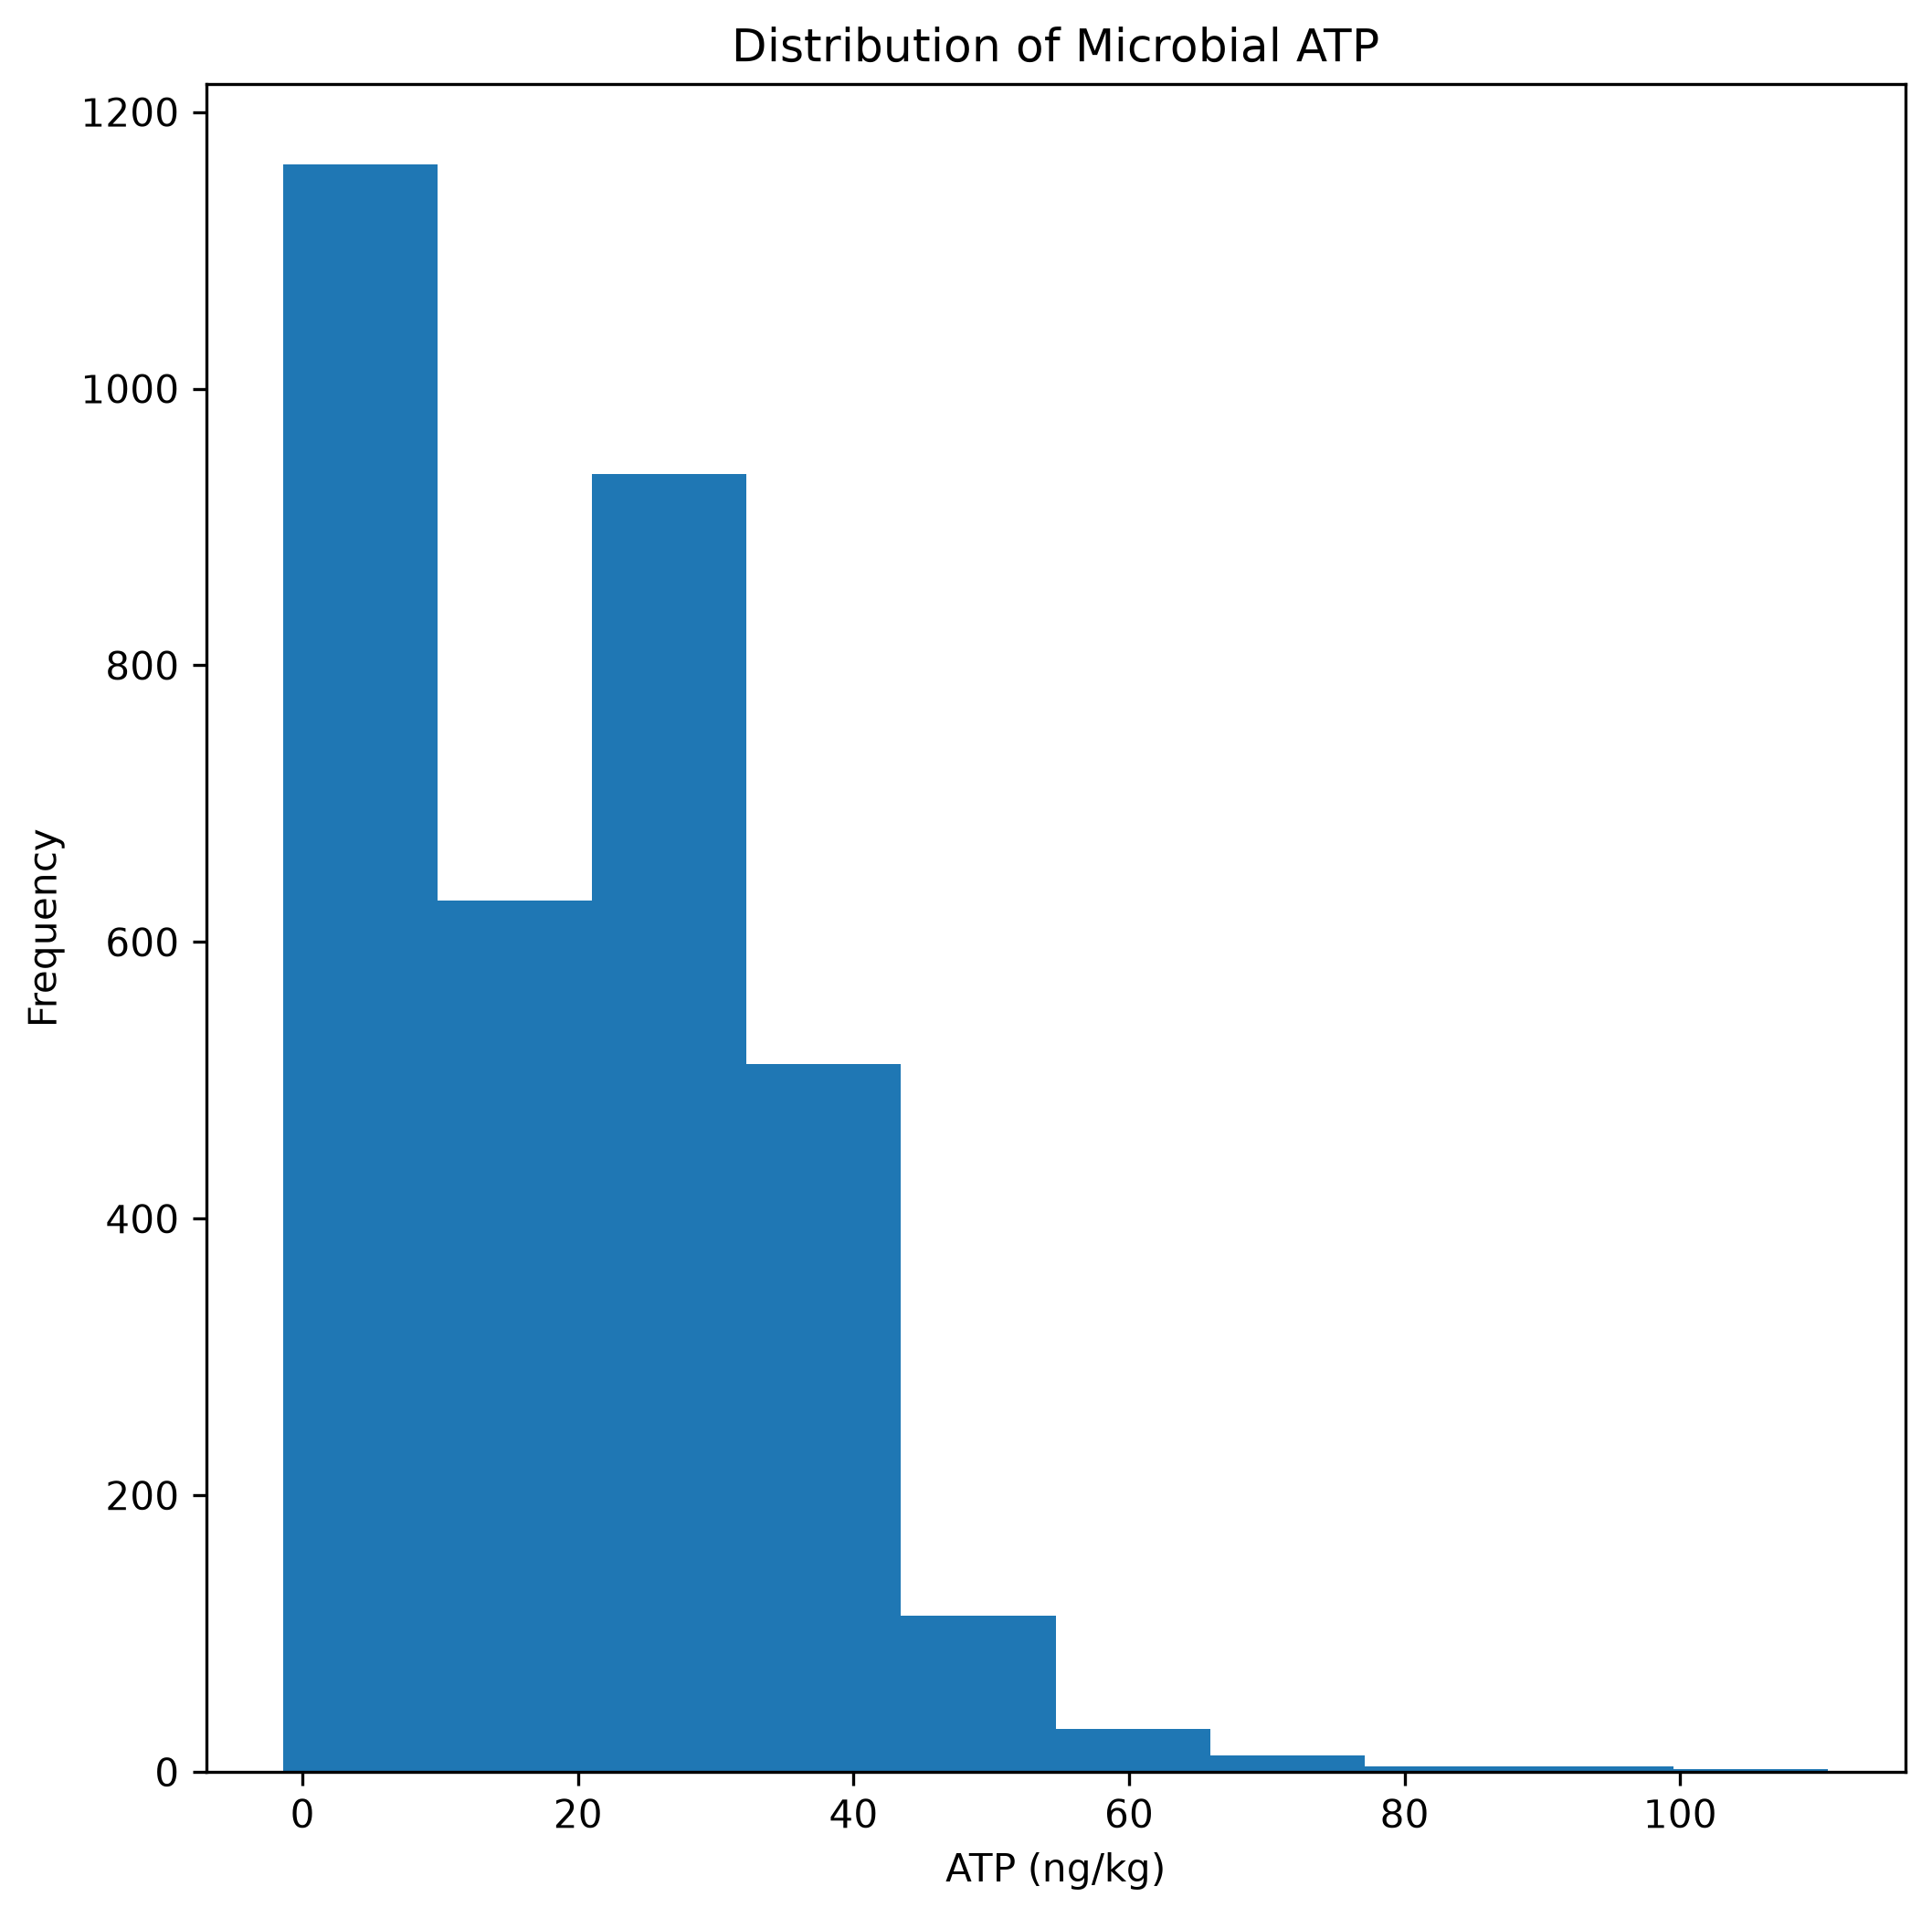

In [13]:
# histogram
fig, ax = plt.subplots(1, figsize=(8, 8), dpi=300)

plt.hist(atp["ATP"].dropna())

plt.title("Distribution of Microbial ATP")
plt.xlabel("ATP (ng/kg)")
plt.ylabel("Frequency")

plt.show()

ATP is skewed to the right, most of the values are below 40 ng/kg. Some are much higher but not many.

## Does microbial ATP change with pressure (depth)?

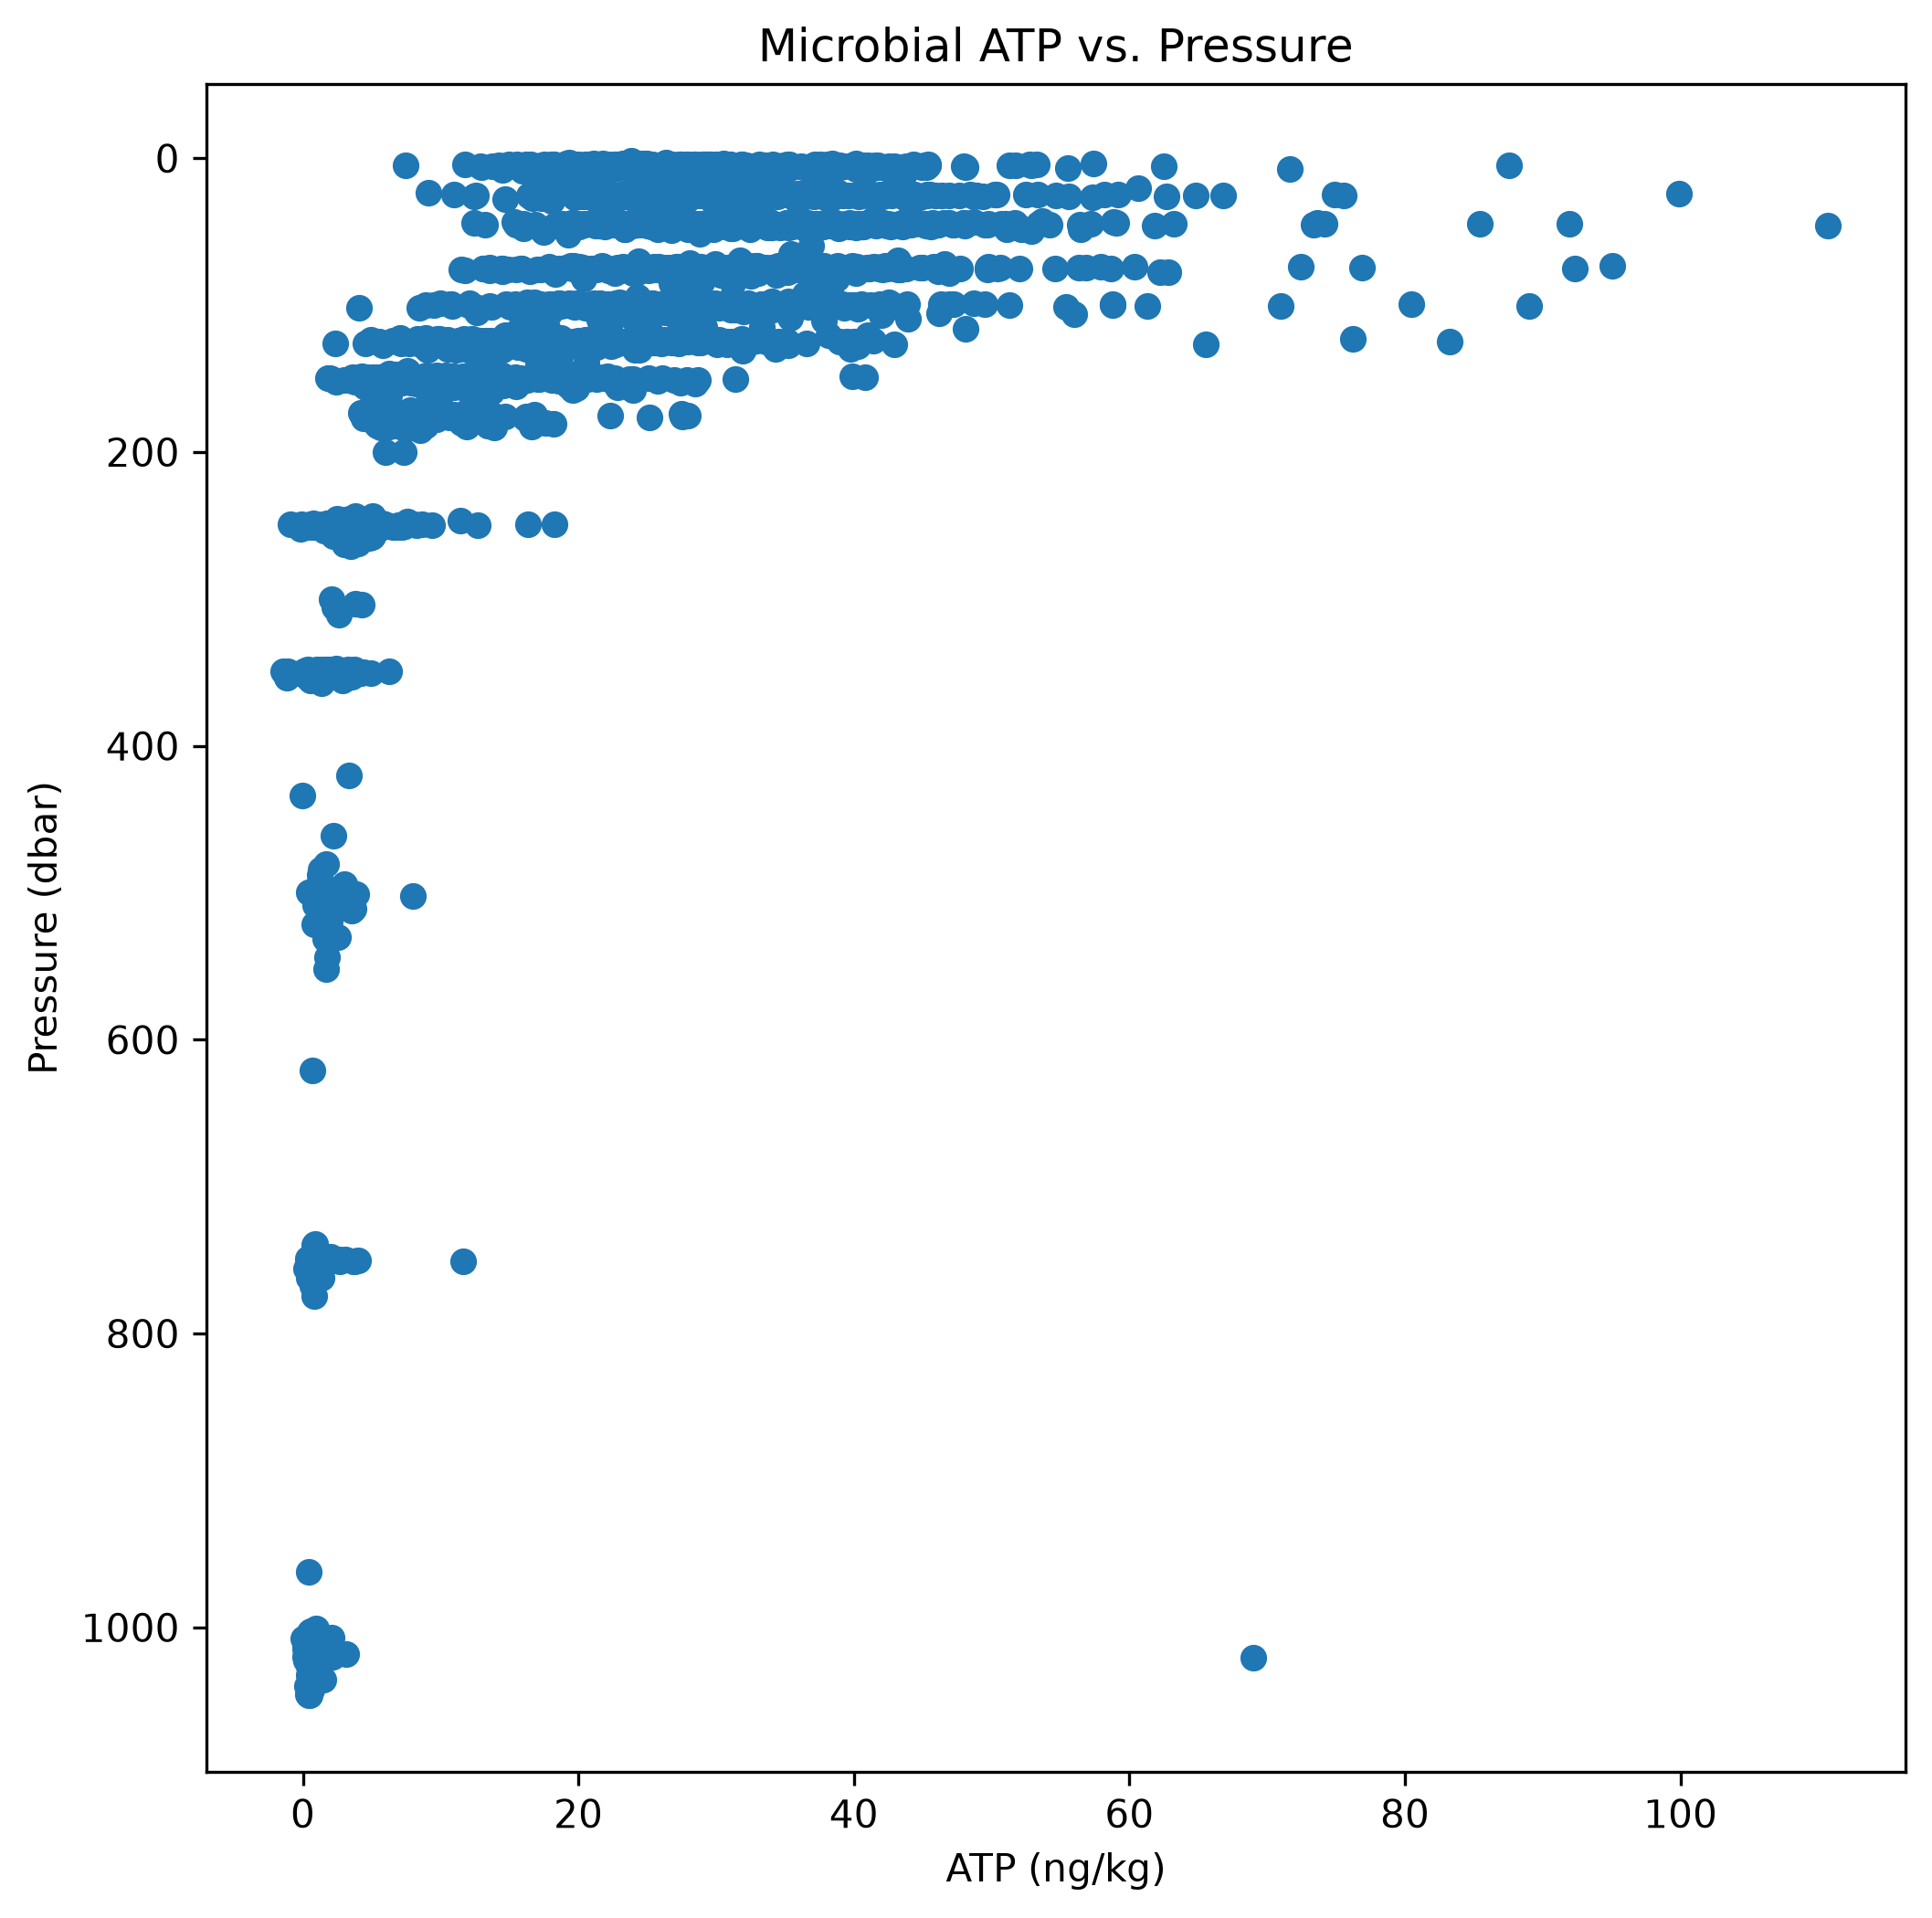

In [14]:
fig, ax = plt.subplots(1, figsize=(8, 8), dpi=300)

plt.scatter(atp["ATP"], atp["Pressure"])

plt.title("Microbial ATP vs. Pressure")
plt.xlabel("ATP (ng/kg)")
plt.ylabel("Pressure (dbar)")

plt.gca().invert_yaxis()

plt.show()

ATP decreases as pressure increases. This would make sense because there is a large amount of microbial activity that occurs at the surface of the water column. When pressures/depths exceed 400 dbar/m the ATP values are almost 0 ng/kg.

## ATP changing over time?

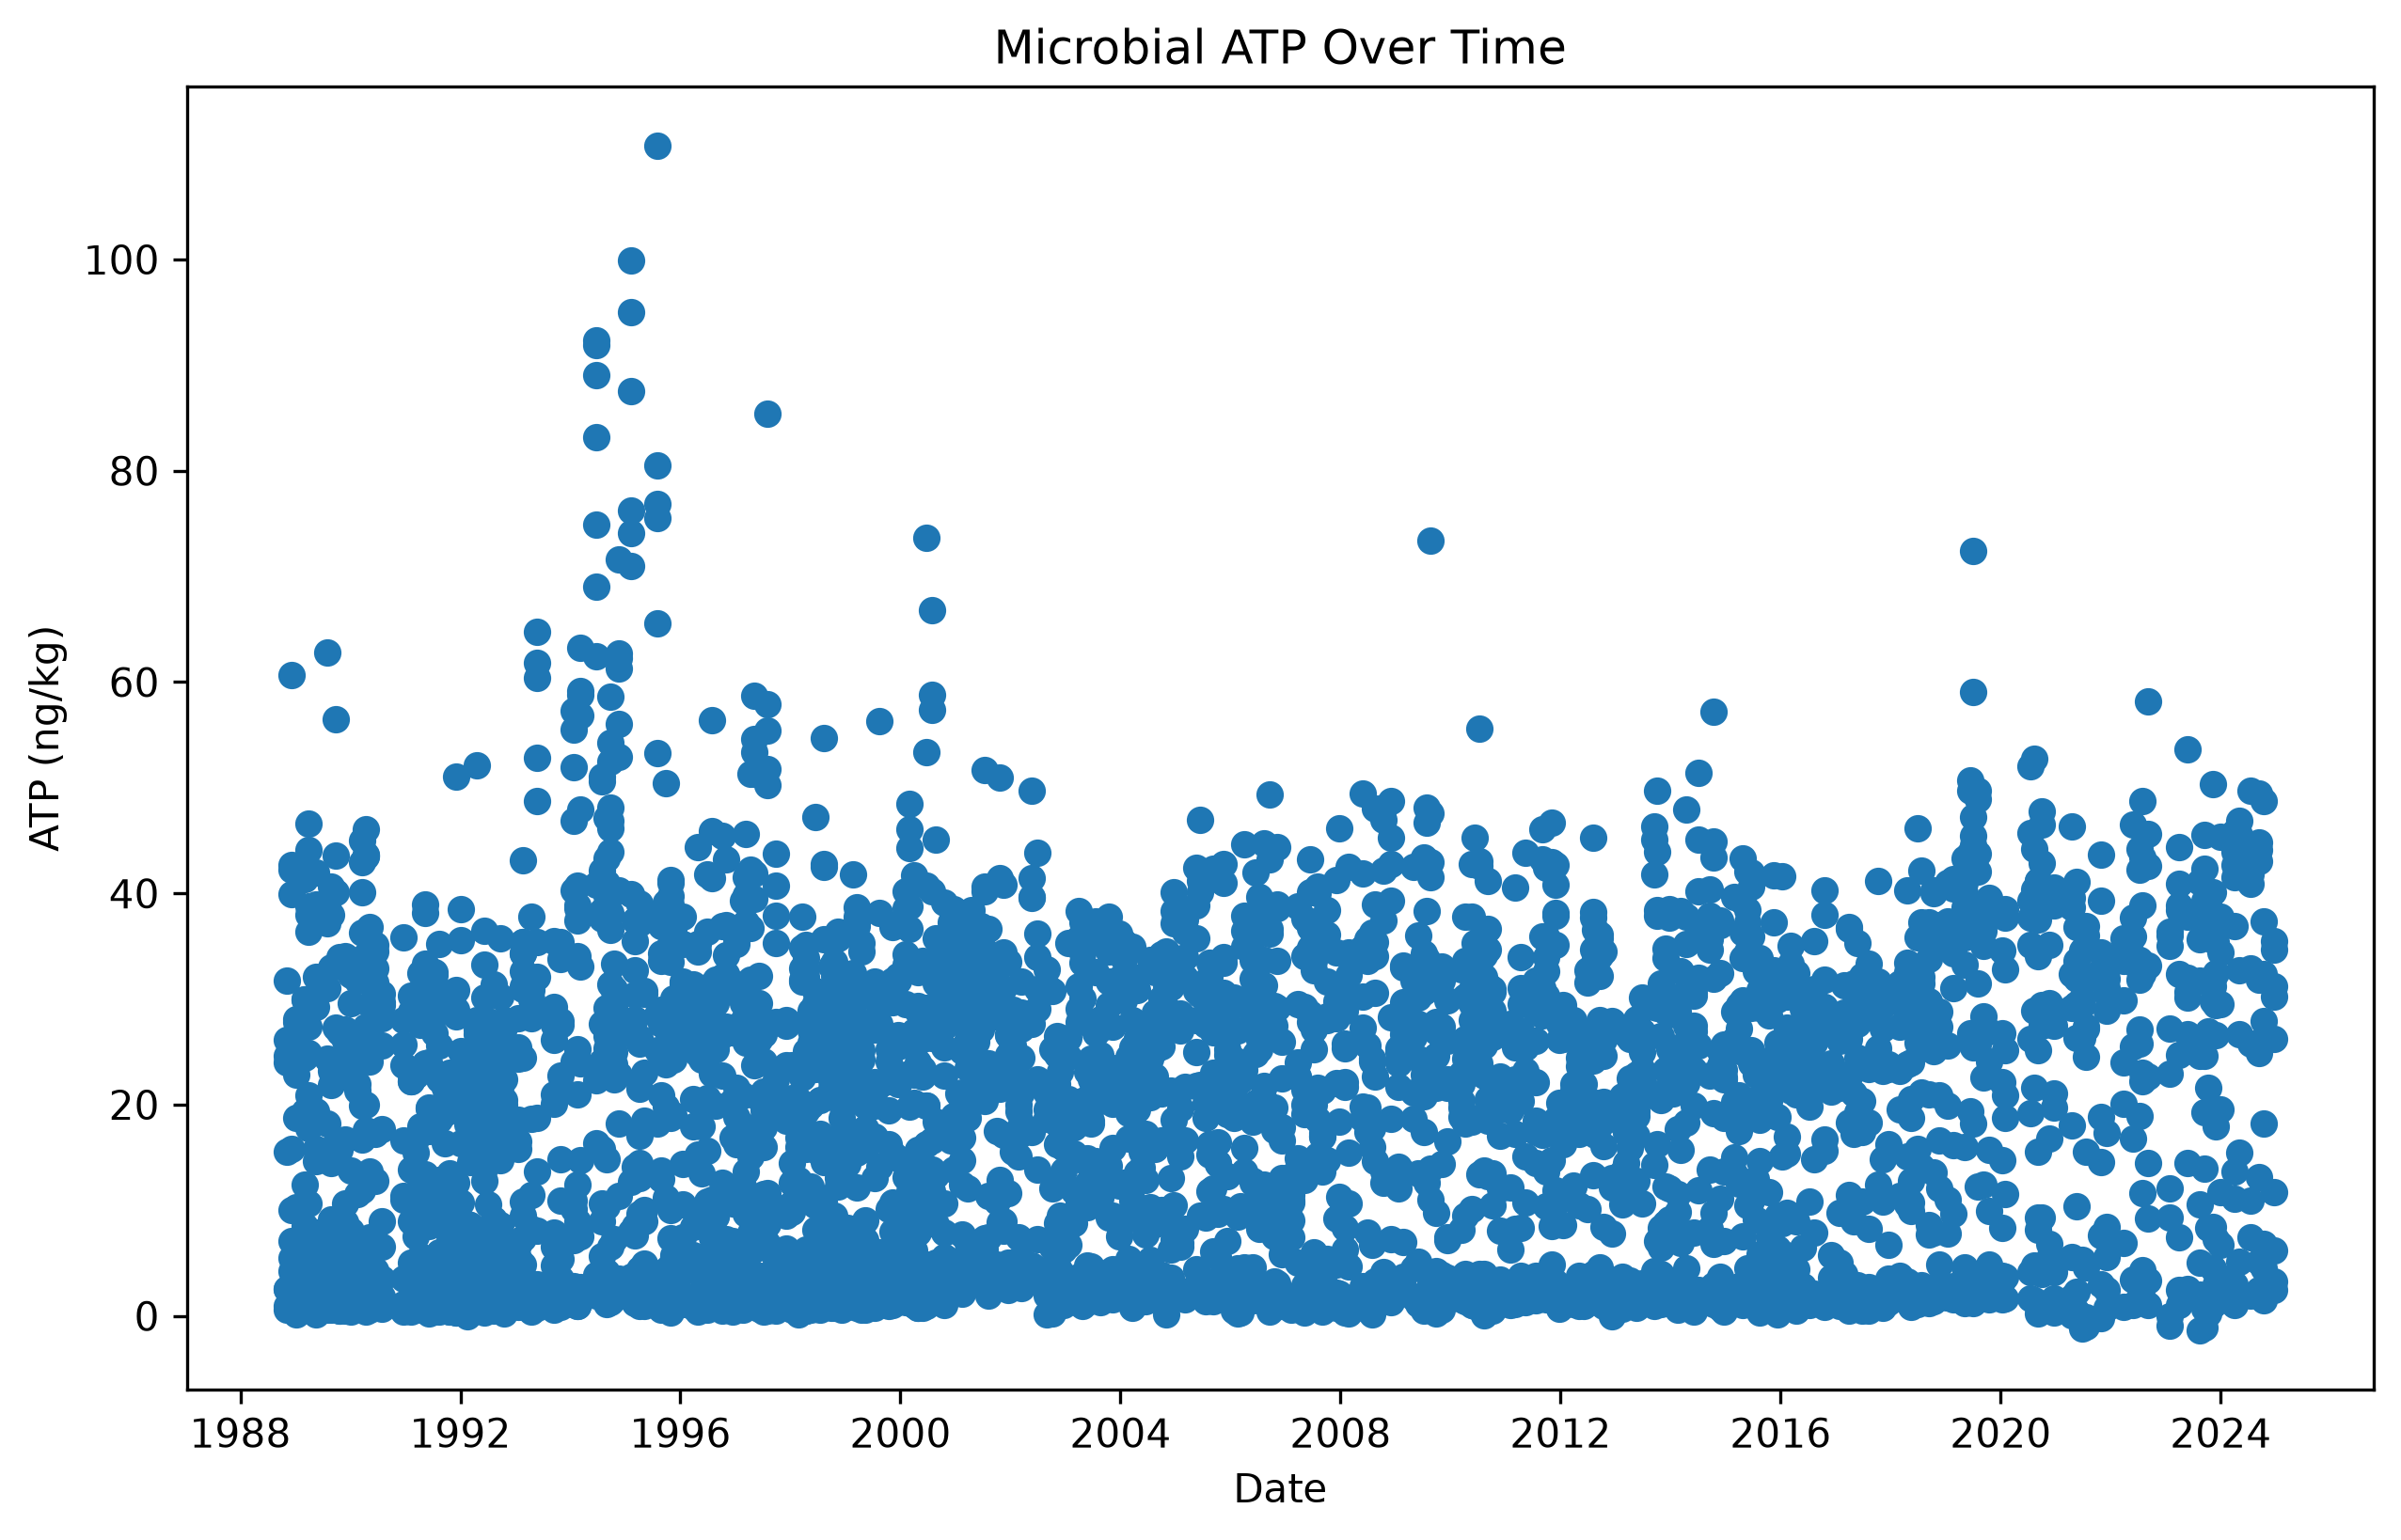

In [15]:
fig, ax = plt.subplots(1, figsize=(10, 6), dpi=300)

plt.scatter(atp["Date"], atp["ATP"])

plt.title("Microbial ATP Over Time")
plt.xlabel("Date")
plt.ylabel("ATP (ng/kg)")

plt.show()

It doesnt look like there is a trend with ATP values over time. Since ATP is a live-microbial biomass indicator, ATP should change significantly with depth. Pressure will be used as a unit of depth since the data set did not include depth as a variable.

## What does ATP with time look like in the upper 100m (100dbar) of the water column?

In [16]:
shallow = atp[atp["Pressure"] <= 100]
# create a vector with all ATP values that are near the surface (upper 100m)

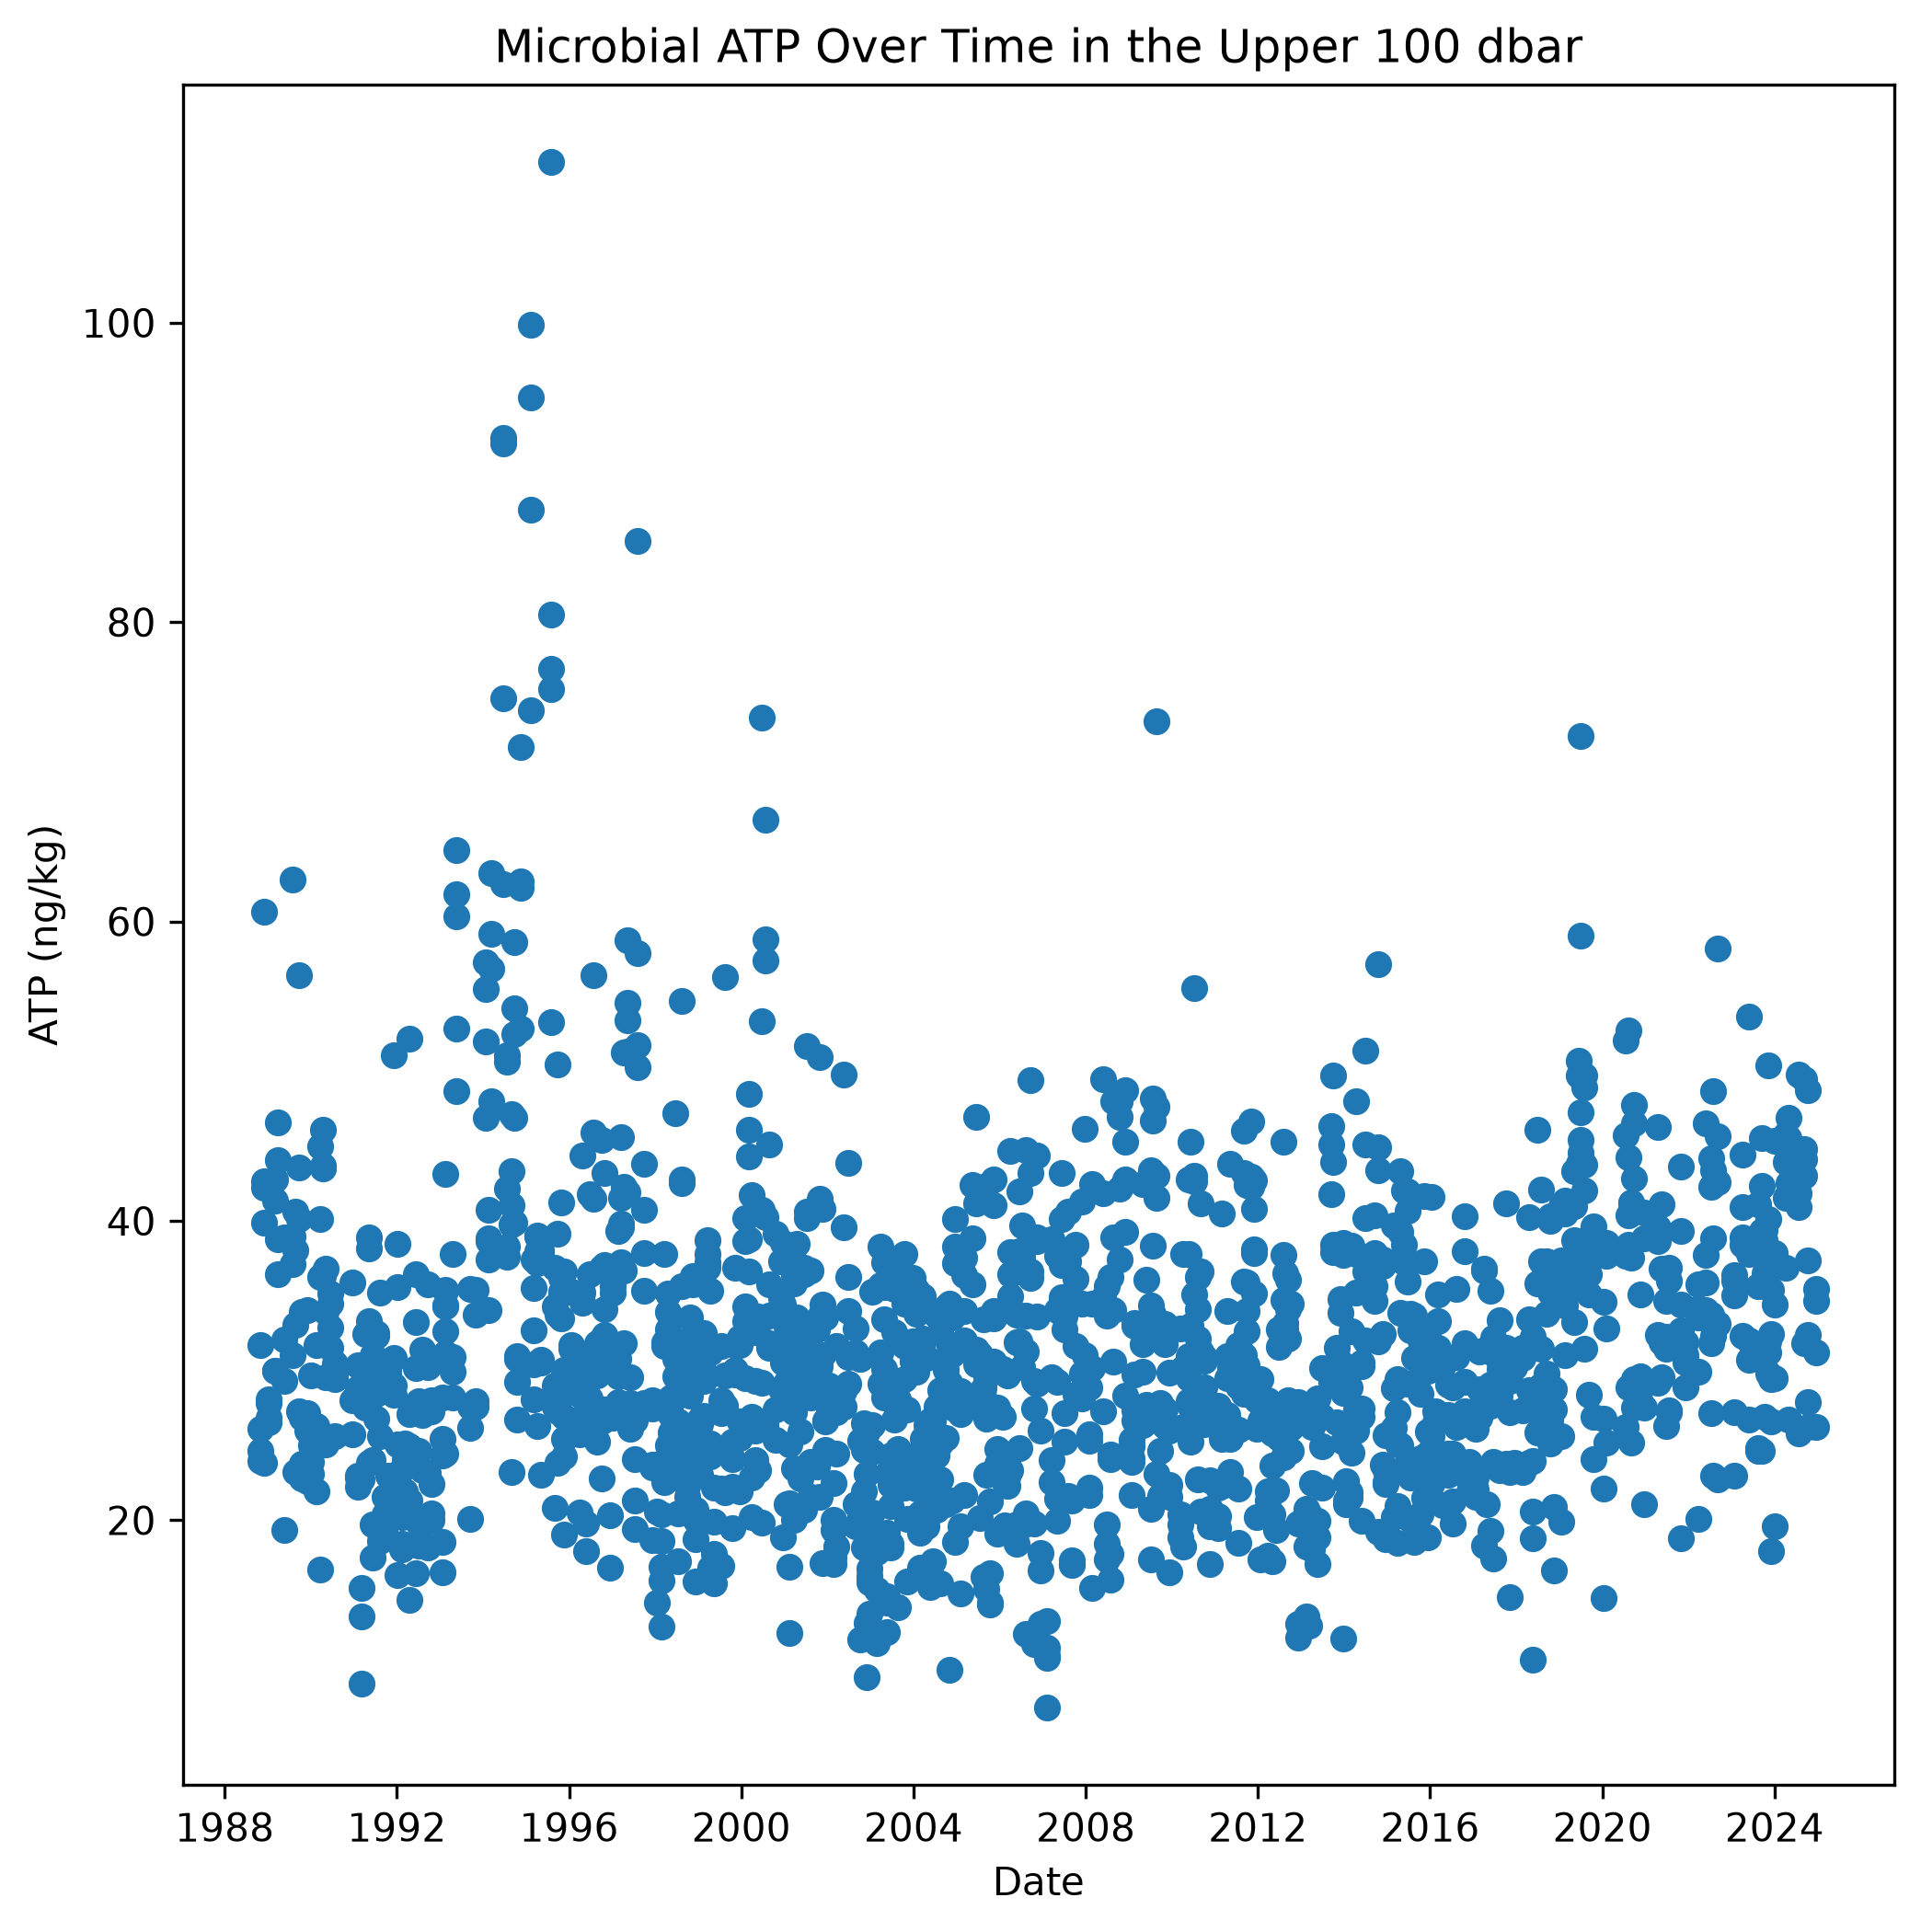

In [17]:
fig, ax = plt.subplots(1, figsize=(8, 8), dpi=300)

plt.scatter(shallow["Date"], shallow["ATP"])

plt.title("Microbial ATP Over Time in the Upper 100 dbar")
plt.xlabel("Date")
plt.ylabel("ATP (ng/kg)")

plt.show()

When ATP values are ploted over time in the upper 100 meters of the water column, there is still no obvious trend occuring. It looks like there was an increase between 1992 and 1996, but it lowered back down to the other values afterwards. It doesn't look like there is any major temporal pattern. 

## Spatial and Temporal Coverage

In [18]:
print(atp["Date"].min())
print(atp["Date"].max())

print(atp["Latitude [degrees_north]"].min())
print(atp["Latitude [degrees_north]"].max())

print(atp["Longitude [degrees_east]"].min())
print(atp["Longitude [degrees_east]"].max())

print(atp["Pressure"].min())
print(atp["Pressure"].max())

print(atp["Cruise"].nunique())

1988-11-01 20:36:00
2024-12-20 23:48:00
22.605
22.876699
-158.146698
-157.886703
1.8
1046.19995
338


ATP measurements were collected from November 1988 to December 2024. There is data from 338 different cruises. The samples were taken approximately 22.61-22.87 deg N and 157.89-158.15 deg W around the ALOHA station in Hawaii. ATP depths were between 1.8 and 1046 meters deep, which gives a large section of the water column to be observed for ATP. 

In [19]:
# how many cruises were there per year
atp["Year"] = atp["Date"].dt.year

atp.groupby("Year")["Cruise"].nunique()

Year
1988     2
1989     9
1990     8
1991    10
1992     9
1993     6
1994     9
1995     9
1996    10
1997    10
1998    12
1999    10
2000    11
2001    12
2002    10
2003    11
2004    12
2005    10
2006    12
2007    10
2008     8
2009    10
2010     9
2011    10
2012    10
2013    10
2014    10
2015    10
2016     9
2017    10
2018     8
2019     8
2020     8
2021     6
2022     5
2023     9
2024     6
Name: Cruise, dtype: int64

There were approximatley 8-12 cruises that took ATP data every year since 1988, with the exception of the years 1988, 1993, 2021, 2022, and 2024. 

## Data Integration and Overlap

In [20]:
atp[["ATP",
    "Pressure",
    "Date",
    "CTD Temperature (CTDTMP) [ITS-90]",
    "CTD Salinity (CTDSAL) [PSS-78]",
    "CTD Oxygen (CTDOXY) [umol/kg]" ]].notna().sum()
# How many other variables are there that alighn with ATP values

ATP                                  3408
Pressure                             3403
Date                                 3408
CTD Temperature (CTDTMP) [ITS-90]    3403
CTD Salinity (CTDSAL) [PSS-78]       3403
CTD Oxygen (CTDOXY) [umol/kg]        3378
dtype: int64

All the variables were found int he same HOT dataset, so there are no seperate data sets that needed to be combined. All of the ATP data has a date, and all but five ATP values have an associated pressure, CTD temperature, and CTD salinity. 30 ATP values do not have CTD oxygen values linked to them. Since all of this data is from the same station, the data does not need to be altered spatially or temporally; However, ATP did have to be indexed to show all of the connected data. There are many ATP blank sections in the data set because the cruises did not collect continuous ATP data throughout the water column. The Rosette system collected water at specific depths. 

When I decide to bring in the BATS data to estimate the ATP values, I will have to make sure that all of the data is in the same units and I can map it as long as the projections of the two datasets are the same. 

## Ideas I had while creating the outline

I think it would be a good idea to see any similarities with other variables that can be selected with this dataset and try to estimate what the ATP values could be in other areas. For instance, I could get the HOT data for chlorophyll or carbon and then estimate what the ATP might be in BATS if I used the correlation between the cholorphyll, carbon, and ATP values. 